In [ ]:
!pip install sklearn
!pip install tensorflow

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
!pip install scikit-learn
!pip install xgboost

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import xgboost as xgb

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shreyacgosavi/palm-dataset-anemia")

print("Path to dataset files:", path)

100%|██████████| 241M/241M [00:14<00:00, 17.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shreyacgosavi/palm-dataset-anemia/versions/1


In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

def load_images_and_labels(dataset_path, image_size=(224, 224)):
    """
    Load images and assign labels:
    - 'Non...' → 0
    - others → 1 (Anemic)
    """
    images = []
    labels = []

    count_anemic = 0
    count_non = 0
    skipped = 0

    for file_name in os.listdir(dataset_path):

        # ✅ Only process images
        if not file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        file_path = os.path.join(dataset_path, file_name)

        try:
            # 🔹 Label logic
            if file_name.lower().startswith('non'):
                labels.append(0)
                count_non += 1
            else:
                labels.append(1)
                count_anemic += 1

            # 🔹 Load + preprocess
            img = image.load_img(file_path, target_size=image_size)
            img_array = image.img_to_array(img)
            img_array = preprocess_input(img_array)

            images.append(img_array)

        except Exception as e:
            print(f"Skipped {file_name}: {e}")
            skipped += 1

    print(f"✅ Anemic: {count_anemic}")
    print(f"✅ Non-Anemic: {count_non}")
    print(f"⚠️ Skipped: {skipped}")

    return np.array(images, dtype='float32'), np.array(labels)

In [ ]:
import os

X, y = load_images_and_labels(os.path.join(path, 'Palm'))

print("Data shape:", X.shape, y.shape)

✅ Anemic: 2562
✅ Non-Anemic: 1698
⚠️ Skipped: 0
Data shape: (4260, 224, 224, 3) (4260,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)

model = Model(inputs=base_model.input, outputs=x)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
print("🚀 Extracting features...")

X_train_features = model.predict(X_train, batch_size=32, verbose=1)
X_test_features = model.predict(X_test, batch_size=32, verbose=1)

print("Feature shape:", X_train_features.shape)

🚀 Extracting features...
107/107 ━━━━━━━━━━━━━━━━━━━━ 34s 165ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 456ms/step
Feature shape: (3408, 1280)


In [ ]:
!pip install xgboost
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective='binary:logistic',
    tree_method='hist'  # 🔥 GPU acceleration
)

xgb_model.fit(X_train_features, y_train)
y_pred = xgb_model.predict(X_test_features)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
def predict_single_image(img_path, model, xgb_model, image_size=(224, 224)):
    from tensorflow.keras.preprocessing import image
    from tensorflow.keras.applications.efficientnet import preprocess_input
    import numpy as np

    # Load image
    img = image.load_img(img_path, target_size=image_size)
    img_array = image.img_to_array(img)

    # Preprocess
    img_array = preprocess_input(img_array)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Extract features using EfficientNet
    features = model.predict(img_array)

    # Predict using XGBoost
    prob = xgb_model.predict_proba(features)[0][1]
    pred = (prob > 0.5).astype(int)

    # Output
    if pred == 1:
        print(f"🩸 Prediction: ANEMIC (Confidence: {prob:.2f})")
    else:
        print(f"🟢 Prediction: NON-ANEMIC (Confidence: {1 - prob:.2f})")

    return pred, prob
    model.save("anemia_model.keras")




✅ Accuracy: 0.9577464788732394

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.91      0.95       340
           1       0.95      0.99      0.97       512

    accuracy                           0.96       852
   macro avg       0.96      0.95      0.96       852
weighted avg       0.96      0.96      0.96       852



Download this below one

In [ ]:
# ==========================
# INSTALL + TRAIN XGBOOST
# ==========================
!pip install xgboost

import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective='binary:logistic',
    tree_method='hist'
)

xgb_model.fit(X_train_features, y_train)

y_pred = xgb_model.predict(X_test_features)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))


# ==========================
# PREDICTION FUNCTION
# ==========================
def predict_single_image(img_path, model, xgb_model, image_size=(224, 224)):
    from tensorflow.keras.preprocessing import image
    from tensorflow.keras.applications.efficientnet import preprocess_input
    import numpy as np

    img = image.load_img(img_path, target_size=image_size)
    img_array = image.img_to_array(img)

    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    features = model.predict(img_array)

    prob = xgb_model.predict_proba(features)[0][1]
    pred = int(prob > 0.5)

    if pred == 1:
        print(f"🩸 Prediction: ANEMIC (Confidence: {prob:.2f})")
    else:
        print(f"🟢 Prediction: NON-ANEMIC (Confidence: {1 - prob:.2f})")

    return pred, prob


# ==========================
# SAVE MODELS (Palm_anemia_96)
# ==========================
import joblib
from google.colab import drive, files

# Mount Drive
drive.mount('/content/drive')

# File names
kera_name = "Palm_anemia_96_feature_extractor.keras"
xgb_name = "Palm_anemia_96_xgb.pkl"

# Paths
kera_drive_path = f"/content/drive/MyDrive/{kera_name}"
xgb_drive_path = f"/content/drive/MyDrive/{xgb_name}"

# Save to Drive
model.save(kera_drive_path)
joblib.dump(xgb_model, xgb_drive_path)

print("☁️ Models saved to Google Drive!")

# Save locally (for download)
model.save(kera_name)
joblib.dump(xgb_model, xgb_name)

print("✅ Models saved locally!")

# Download
files.download(kera_name)
files.download(xgb_name)

print("Download started!")

✅ Accuracy: 0.9577464788732394

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.91      0.95       340
           1       0.95      0.99      0.97       512

    accuracy                           0.96       852
   macro avg       0.96      0.95      0.96       852
weighted avg       0.96      0.96      0.96       852

Mounted at /content/drive
☁️ Models saved to Google Drive!
✅ Models saved locally!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!


In [ ]:
from google.colab import files
uploaded = files.upload()
img_path = "Unseen_palm.jpeg"
predict_single_image(img_path, model, xgb_model)

Saving Unseen_palm.jpeg to Unseen_palm.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
🩸 Prediction: ANEMIC (Confidence: 0.95)


(1, np.float32(0.94702893))

In [ ]:
import os
print(os.listdir('/content'))

['.config', 'sample_data']


*4

In [ ]:
from tensorflow.keras.models import load_model
import joblib

model = load_model('/content/drive/MyDrive/Palm_anemia_96_feature_extractor.keras')
print("✅ Models loaded successfully!")

✅ Models loaded successfully!


In [ ]:
from google.colab import files
uploaded = files.upload()
import joblib
xgb_model = joblib.load("Palm_anemia_96_xgb.pkl")

Saving Palm_anemia_96_feature_extractor.keras to Palm_anemia_96_feature_extractor (1).keras


👇👇👇

In [ ]:
# LOAD EVERYTHING ONCE

from tensorflow.keras.models import load_model
import joblib

model = load_model('/content/drive/MyDrive/Palm_anemia_96_feature_extractor.keras')
xgb_model = joblib.load('/content/drive/MyDrive/Palm_anemia_96_xgb.pkl')

def predict_single_image(img_path, model, xgb_model):
    from tensorflow.keras.preprocessing import image
    from tensorflow.keras.applications.efficientnet import preprocess_input
    import numpy as np
    import matplotlib.pyplot as plt

    img = image.load_img(img_path, target_size=(224, 224))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    features = model.predict(img_array)
    prob = xgb_model.predict_proba(features)[0][1]
    pred = int(prob > 0.5)

    label = "ANEMIC" if pred else "NON-ANEMIC"
    confidence = prob if pred else (1 - prob)

    print(f"\n🧪 RESULT: {label}")
    print(f"📊 Confidence: {confidence:.2f}")

Saving Unseen_palm.jpeg to Unseen_palm (2).jpeg


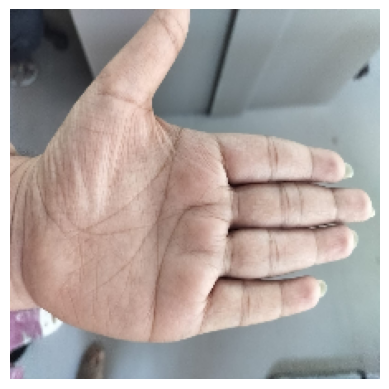

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step

🧪 RESULT: ANEMIC
📊 Confidence: 0.95


In [ ]:
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
predict_single_image(img_path, model, xgb_model)

Saving seen_healthy.jpg to seen_healthy.jpg


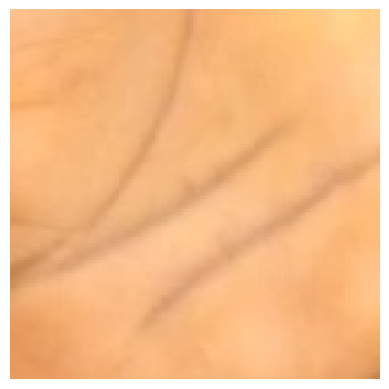

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

🧪 RESULT: NON-ANEMIC
📊 Confidence: 0.98


In [ ]:
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0] # Get the first uploaded filename
predict_single_image(img_path, model, xgb_model)

Saving seen_anemic_palm1.png to seen_anemic_palm1.png


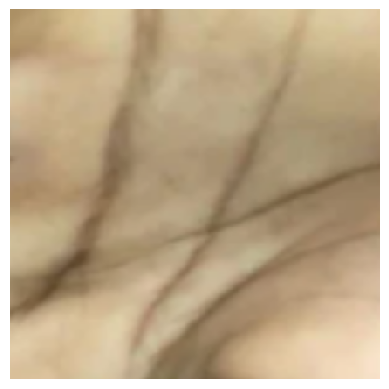

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

🧪 RESULT: ANEMIC
📊 Confidence: 0.98


In [ ]:
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
predict_single_image(img_path, model, xgb_model)